# **Seasonal Flu Vaccine Prediction.**
## **Data Cleaning Notebook:**
### CRISP-DM Framework : Business Understaning | Data Understanding | Data Preparation

### **Data Source:** National 2009 HINI Flu Survey

### Notebook Purpose:
This notebook covers the first stage of our data pipeline:
- Business Understanding - defining our stakeholder and problem.
- Data Understanding - exploring and understanding our data.
- Data Preparation - Cleaning data ready for analysis and modelling.

### Expected Notebook Output.
- Cleaned dataset saved to `Data/Cleaned_data/cleaned_data.csv`

### Library Imports

In [61]:
# IMPORTS

#Standard Libraries
import warnings
warnings.filterwarnings("ignore")

#Core Libraries
import numpy as np
import pandas as pd

#Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

#Scikit-Learn Libraries
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder
)

#Scikit-Learn Imputation Libraries
from sklearn.impute import SimpleImputer

#Scikit-learn Model Selection Libraries
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

#Scikit-Learn Models
from sklearn.linear_model import (
    LogisticRegression,
    Ridge,
    Lasso
)

#Decision Tree Models
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Ensmble Models
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

#Scikit-Learn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

#Statsmodels Libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Display Settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print ("All Libraries are imported successfuly and ready to use")



All Libraries are imported successfuly and ready to use


## **Business Understanding.**


## **Background:**
The 2009 HINI influenza pandemic, commonly known as "swine flu", swept across the world beginning in spring 2009, responsible for an estimated 151,000 to 575,000 deaths globally in its first year.In response, the United States governement launched a vaccination campaign making HINI vaccines publicly available in October 2009.

In late 2009 and early 2010, the UNited States conducted the National 2009 HINI Flu Survey to monitor vaccination rates. This phone survey asked respondents whether they had received HINI and Seasonal Flu vaccines alongside questions about theri backgrounds, opinions, and health behaviors.

**Note on Context:** While this dataset originates from the 2009 US HINI Flu Survey, the behavioral, opinion, and demographic drivers of vaccine hesistancy are universal public health phenomena. The methodology and insights generated are directly applicable to the Kenyan public health context, particularly given Kenya's ongoing challenges with seasonal influenza vaccination uptake. Kenya genrally experiences two flu seasons annualy - March to May and October and December - aligned with the long and short rains, mking seasonal flu vaccination a recurring a nd critical public health challenge.

### **Stakeholders:**
This project adopts a dual - level stakeholder framework reflecting real epidemiological practice, where population-level patterns inform facility-level interventions. Our stakeholders operate within the Kenyan public health system:

**|Stakeholder | Role | What They Need |**

**|County Director of Health (CDoH) |** Responsible for public health Surveillance and community reach at County Level | Identify which communities to target for seasonal flu vaccination outreach every flu season |

**|Chief Executive Officers: Kenyatta Referral Hospital $ Mbagathi County Hospital|** Responsible for clinical interventions in public hospitals | Identify which patients to flag for additional encouragement from clinicians during consultations |

### **Business Problem**
Can we predict whether an individual will receive the seasonal flu vaccine based on their background, opinions, and health behaviors?

Understanding the drivers of seasonal flu vaccination uptake will allow our stakeholders to:

- **County Director of Health:** Use demographic and behavioral patterns to target community outreach programs at popualtions with consistently low vaccination rates every flu season, ensuring more effecient allocation of public health resources.

- **County Referall Hospital CEOs:** Use clinical predictors such as chronic medical conditions, doctor recommendations and health insuarance status to identify and proactively engage patients who are unlikely to vaccinate during routine clinical consultations.

### **Why Machine Learning?**
Traditional surveys can often pinpoint and tell us vaccination rates but cannot predict future or identify at-risk individuals before vaccination campaigns begin.

A classification model allows us to :
- Predict seasonal flu vaccination likelihood for new individuals.
- Identify the most important drivers of vaccination behavior.
- Generate actionable and specific recommendations for both 
  community outreach and clinical intervention.
- Move from descriptive analysis to predictive intervention.
- Build a reusable framework that remains relevant every flu season.





### **Project Scope:**
| **Target Variable** | `seasonal_vaccine` only (binary: 0 = not vaccinated, 1 = vaccinated) |

| **In Scope** | Predicting seasonal flu vaccination behavior and identifying its strongest drivers |

| **Out of Scope** | Predicting H1N1 vaccination, real-time prediction, causal inference, private sector analysis |

| **Success Metric** | ROC AUC score — measures the model's ability to distinguish between vaccinated and unvaccinated individuals |

| **Context** | Methodology adapted from US 2009 H1N1 Flu Survey for application in Kenyan public health setting |

## **Data Understanding.**


### **Dataset Description:**
The dataset comes from the National 2009 H1N1 Flu Survey conducted 
by the United States government. We are working with four files:

-  `training_set_features.csv` : 35 features for survey respondents | 26,707 |
-  `training_set_labels.csv` : Target variables for survey respondents | 26,707 | seasonal_vaccine only |
-  `test_set_features.csv` : Features for unseen respondents | 26,708 | 
-  `submission_format.csv` : Competition submission template | 26,708 |

My main focus is the  `training_set_features.csv` and `training_set_labels.csv`, this is because the  `test_set_features.csv` dataset has unseen data that was needed for the competition submission file while `submission_format.csv` is purely for the competition submission format.

Therefore, for my analysis i will exclusively focus on predicting 'seasonal_vaccine' as my binary target variable where:

- **0** = Individual did not receive seasonal flu vaccine
- **1** = Individual received seasonal flu vaccine

### **Loading the Data.**

In [62]:
#DATA LOADING

#Define the path to the dataset
data_path = "../Data/Raw_data/"
cleaned_path = "../Data/Cleaned_data/"

#Load the dataset
#Load training feeatures
features_df = pd.read_csv(data_path + "training_set_features.csv")
#Load training labels
labels_df = pd.read_csv(data_path + "training_set_labels.csv")

#Remaining files: was not necessary but i loaded to acknowlege their existence and to be ready if needed in the future.
test_features_df = pd.read_csv(data_path + "test_set_features.csv", index_col = 0)
submission_df = pd.read_csv(data_path + "submission_format.csv", index_col = 0)



In [63]:
#Drop h1n1_vaccine from the column of the training label as it out of scope for this analysis which needed working with only one classification.
# Defensive drop of h1n1_vaccine - out of scope for this project: did this because the first time i tried to drop it would tell me i have already dropped the column.
# Check first to avoid KeyError on repeated runs
if "h1n1_vaccine" in labels_df.columns:
    labels_df = labels_df.drop(columns=["h1n1_vaccine"])
    print("✓ h1n1_vaccine dropped successfully")
else:
    print("✓ h1n1_vaccine already dropped - skipping")

#Confirm the sahpes of the datasets
print(f"Training Features : {features_df.shape}")
print(f"Training Labels   : {labels_df.shape}")
print(f"Test Features     : {test_features_df.shape} (not used)")
print(f"Submission Format : {submission_df.shape} (not used)")

✓ h1n1_vaccine dropped successfully
Training Features : (26707, 36)
Training Labels   : (26707, 2)
Test Features     : (26708, 35) (not used)
Submission Format : (26708, 2) (not used)


In [64]:
#MERGE THE TRAINING FEATURES AND LABELS.
# Merge features and labels on respondent_id ensuring each respondent's features align with their vaccination status
if "seasonal_vaccine" not in features_df.columns:
    df = features_df.merge(labels_df, on="respondent_id")
    print("\n Features and labels merged successfully")
else:
    df = features_df.copy()
    print("\n Already merged - skipping")

# Set respondent_id as index to prevent it from being treated
# as a feature during modeling
if df.index.name != "respondent_id": #came across an error when rerunning the code and added this as it checks whether respondent_id is already the index before trying to set it again.
    df = df.set_index("respondent_id")
    print(" respondent_id set as index successfully")
else:
    print(" respondent_id already set as index - skipping")

df.head(5)


 Features and labels merged successfully
 respondent_id set as index successfully


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0


### **Initial Data Inspection:**


In [65]:
#Initial Data Inspection
#Shape of the dataset
print(f"Rows     : {df.shape[0]}")
print(f"Columns  : {df.shape[1]}")

#Column names and data types
print ("|nColumn names and data types:")
print(df.dtypes)

#Basic statistics for numeric columns
print("|Basic Statistics for Numeric Columns:")
print(df.describe())

Rows     : 26707
Columns  : 36
|nColumn names and data types:
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
se

In [66]:
#Data types Summary -Summary in the dataset that helps us better understand the types of data we are working with.

# Separate numeric and categorical columns.
# Exclude target variable from numeric columns.
numeric_cols = df.select_dtypes(
    include=["float64", "int64"]
).columns.tolist()
#This removes the target variable from the list to prevent data leakage during preprocessing and because seasonal_vaccine is a target and not a feauture.
numeric_cols = [col for col in numeric_cols if col != "seasonal_vaccine"]

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric Feature Columns ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")

print(f"\nCategorical Feature Columns ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

print(f"\nTarget Column : seasonal_vaccine")

Numeric Feature Columns (23):
  - h1n1_concern
  - h1n1_knowledge
  - behavioral_antiviral_meds
  - behavioral_avoidance
  - behavioral_face_mask
  - behavioral_wash_hands
  - behavioral_large_gatherings
  - behavioral_outside_home
  - behavioral_touch_face
  - doctor_recc_h1n1
  - doctor_recc_seasonal
  - chronic_med_condition
  - child_under_6_months
  - health_worker
  - health_insurance
  - opinion_h1n1_vacc_effective
  - opinion_h1n1_risk
  - opinion_h1n1_sick_from_vacc
  - opinion_seas_vacc_effective
  - opinion_seas_risk
  - opinion_seas_sick_from_vacc
  - household_adults
  - household_children

Categorical Feature Columns (12):
  - age_group
  - education
  - race
  - sex
  - income_poverty
  - marital_status
  - rent_or_own
  - employment_status
  - hhs_geo_region
  - census_msa
  - employment_industry
  - employment_occupation

Target Column : seasonal_vaccine


### **Class Balance:**

Before cleaning I checked for the balance of our target variable as an imbalanced target can or will affect model performance and metric choice.

Not Vaccinated (0) : 14272 (53.4%)
Vaccinated     (1) : 12435 (46.6%)


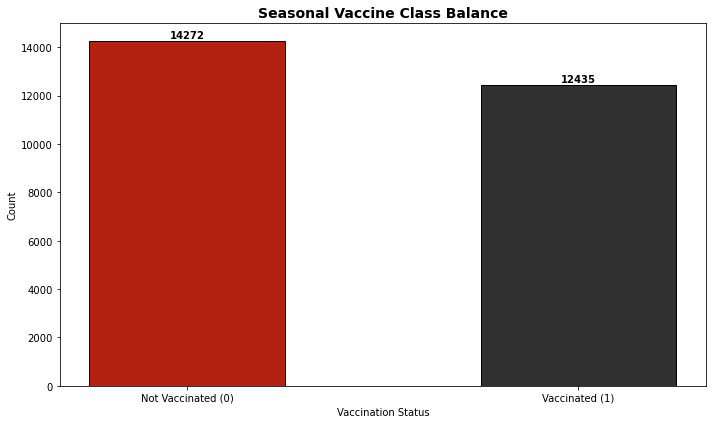

In [67]:
#I checked the  class balance early to determine if resampling techniques will be needed during modeling
# Count and proportion of each class
class_counts = df["seasonal_vaccine"].value_counts()
class_proportions = df["seasonal_vaccine"].value_counts(normalize=True)

print(f"Not Vaccinated (0) : {class_counts[0]} ({class_proportions[0]:.1%})")
print(f"Vaccinated     (1) : {class_counts[1]} ({class_proportions[1]:.1%})")

# Visualize class balance
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    ["Not Vaccinated (0)", "Vaccinated (1)"],
    class_counts,
    color=["#B32111", "#2F302F"],
    edgecolor="black",
    width=0.5
)
ax.set_title("Seasonal Vaccine Class Balance", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("Vaccination Status")

# Add count labels on top of bars for better visualization i.e. to show the exact count of each class
for i, count in enumerate(class_counts):
    ax.text(i, count + 100, str(count), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../Images/class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

#### **Class balance Interpretation:**
The target variable 'seasonal_vaccine' is approximately balanced:
- **Not vaccinated (0) :** 14,272 (53%)
- **Vaccinated (1) :** 12,435 (47%)

This is considered a balanced dataset as neither class dominates the other significantly.
Therefore, this means:

- I do not need resampling techniques such as SMOTE or undersampling/Upweighting.
- Accuracy is a reasonable metric alongside ROC AUC
- Our model will not be biased towards predicting one class over the other.

### **Basic Statistics:**


In [68]:
#Basic Statistics for Numeric Columns
df[numeric_cols].describe().round(2)

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,26615.00,26591.00,26636.00,26499.00,26688.00,26665.00,26620.00,26625.00,26579.00,24547.00,24547.00,25736.00,25887.00,25903.00,14433.00,26316.00,26319.00,26312.00,26245.00,26193.00,26170.00,26458.00,26458.00
mean,1.62,1.26,0.05,0.73,0.07,0.83,0.36,0.34,0.68,0.22,0.33,0.28,0.08,0.11,0.88,3.85,2.34,2.36,4.03,2.72,2.12,0.89,0.53
std,0.91,0.62,0.22,0.45,0.25,0.38,0.48,0.47,0.47,0.41,0.47,0.45,0.28,0.32,0.33,1.01,1.29,1.36,1.09,1.39,1.33,0.75,0.93
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00
25%,1.00,1.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00,1.00,1.00,4.00,2.00,1.00,0.00,0.00
50%,2.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,4.00,2.00,2.00,4.00,2.00,2.00,1.00,0.00
75%,2.00,2.00,0.00,1.00,0.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00,0.00,0.00,1.00,5.00,4.00,4.00,5.00,4.00,4.00,1.00,1.00
max,3.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,5.00,5.00,5.00,5.00,5.00,5.00,3.00,3.00


#### **Basic Statistics Summary/Observations:**
- Missing values are present across multiple columns i.e. count is not 26,707 for most columns, health_insuarance has only 14,433 counts; missing about 46% of values and doctor_rec_h1n1 and doctor_rec_seasonal both show 24,547 missing about 8% of the data.
- All numeric columns are within expected ranges.
- No obvious outliers detected in numeric columns
- Binary columns corectly range between 0 and 1.
- Opinion columns correctly range between 1 and 5.
- Full outlier analysis will be conducted in the Analysis notebook.

## **Data Preparation:**
 This section I perform cleaning steps that are safe to do on the full dataset before splitting. Although from the summary statistics there are no obvious outliers, I do this to prevent any possible data leakage during modelling.

 Preparation includes:

 - Removing duplicates.
 - Visualizing missing values.
 - Saving cleaned data for analysis and modelling.

### **Removing Duplicates:**

In [69]:
#REMOVING DUPLICATES
#Check for duplicates before removal
duplicates_before = df.duplicated().sum()
print(f"Number of duplicate rows before removal: {duplicates_before}")

# Remove duplicates if any exist:
if duplicates_before > 0:
    df = df.drop_duplicates()
    print(f" Duplicates removed")
    print(f"New shape : {df.shape}")
else:
    print(f" No duplicates found - no action needed")
    print(f"Shape remains : {df.shape}")

Number of duplicate rows before removal: 0
 No duplicates found - no action needed
Shape remains : (26707, 36)


#### **Duplicates Observation:**
No duplicate rows were found in the dataset. THis is expected given that each row represents a unique survey respondent identified by 'respondent_id'. No action was required

### **Missing Values:**

In [70]:
#Missing Values Heatmap

#Summary of missing values 
missing_counts = df.isnull().sum()
missing_proportions = df.isnull().mean() * 100
missing_df = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_proportions.round(2)
})

# Show only columns with missing values
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values(
    "Missing Percentage", ascending=False
)

print(f"Columns with missing values : {len(missing_df)}")
print(f"Columns with no missing values : {df.shape[1] - len(missing_df)}")
print(f"\n{missing_df}")

Columns with missing values : 30
Columns with no missing values : 6

                             Missing Count  Missing Percentage
employment_occupation                13470               50.44
employment_industry                  13330               49.91
health_insurance                     12274               45.96
income_poverty                        4423               16.56
doctor_recc_h1n1                      2160                8.09
doctor_recc_seasonal                  2160                8.09
rent_or_own                           2042                7.65
employment_status                     1463                5.48
marital_status                        1408                5.27
education                             1407                5.27
chronic_med_condition                  971                3.64
child_under_6_months                   820                3.07
health_worker                          804                3.01
opinion_seas_sick_from_vacc            537       

### **Missing Values Heatmap:**

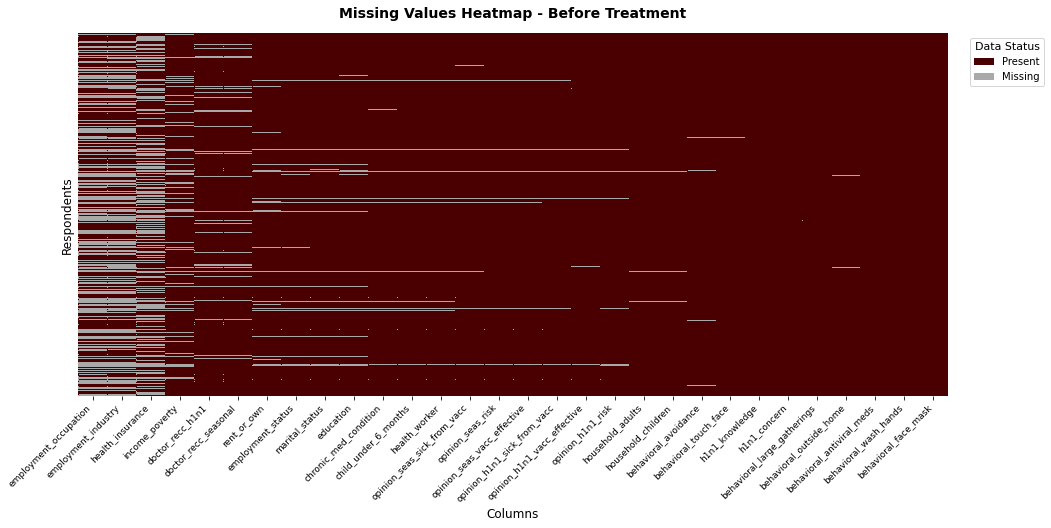

In [71]:
# Missing Values heatmap before Treatment/Imputation


custom_cmap = ListedColormap(["#4A0000", "#A9A9A9"])

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    df[missing_df.index].isnull(),
    yticklabels=False,
    cbar=False,
    cmap=custom_cmap,
    ax=ax
)

ax.set_title(
    "Missing Values Heatmap - Before Treatment",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Columns", fontsize=12)
ax.set_ylabel("Respondents", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=9)

legend_elements = [
    Patch(facecolor="#4A0000", label="Present"),
    Patch(facecolor="#A9A9A9", label="Missing")
]
ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title="Data Status",
    title_fontsize=11,
    frameon=True
)

plt.subplots_adjust(bottom=0.25, right=0.88)
plt.savefig(
    "../Images/missing_values_before.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()




### **Saving the Cleaned Data:**
So far the Cleaned data:
- Has duplicates removed
- Has missing vaues visualized but NOT treated.
- Has not been split, scaled or encoded to avoid data leakage

In [72]:
#Save Cleaned data to the Cleaned_data folder 
df.to_csv(cleaned_path + "cleaned_data.csv", index = True)

print(f" Cleaned data saved successfully")
print(f"  Shape    : {df.shape}")
print(f"  Location : {cleaned_path}cleaned_data.csv")

 Cleaned data saved successfully
  Shape    : (26707, 36)
  Location : ../Data/Cleaned_data/cleaned_data.csv
